In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# 1. Load data from all experiments
results_folder = Path('outputs/individual_experiments')

# Filter experiments
experiment_folders = sorted([f for f in results_folder.iterdir() if f.is_dir() and f.name.startswith('hyp1_bis')])

print(f"Found {len(experiment_folders)} experiment folders")

# Storage for all runs
all_runs_data = []

for exp_folder in experiment_folders:
    by_subject_files = list(exp_folder.glob('*by_subject.json'))
    
    if not by_subject_files:
        print(f"Warning: No by_subject.json file found in {exp_folder.name}")
        continue
    
    with open(by_subject_files[0], 'r') as f:
        data = json.load(f)

    formatted_dict = {}
    for split in data.keys():
        formatted_dict[split] = {subject_dict['subject']: subject_dict for subject_dict in data[split]}
    
    all_runs_data.append(formatted_dict)
    print(f"Loaded data from {exp_folder.name}")

print(f"\nSuccessfully loaded {len(all_runs_data)} runs")

Found 20 experiment folders
Loaded data from hyp1_bis_remove_05_NO_SSL_1
Loaded data from hyp1_bis_remove_05_NO_SSL_10
Loaded data from hyp1_bis_remove_05_NO_SSL_11
Loaded data from hyp1_bis_remove_05_NO_SSL_12
Loaded data from hyp1_bis_remove_05_NO_SSL_13
Loaded data from hyp1_bis_remove_05_NO_SSL_14
Loaded data from hyp1_bis_remove_05_NO_SSL_15
Loaded data from hyp1_bis_remove_05_NO_SSL_16
Loaded data from hyp1_bis_remove_05_NO_SSL_17
Loaded data from hyp1_bis_remove_05_NO_SSL_18
Loaded data from hyp1_bis_remove_05_NO_SSL_19
Loaded data from hyp1_bis_remove_05_NO_SSL_2
Loaded data from hyp1_bis_remove_05_NO_SSL_20
Loaded data from hyp1_bis_remove_05_NO_SSL_3
Loaded data from hyp1_bis_remove_05_NO_SSL_4
Loaded data from hyp1_bis_remove_05_NO_SSL_5
Loaded data from hyp1_bis_remove_05_NO_SSL_6
Loaded data from hyp1_bis_remove_05_NO_SSL_7
Loaded data from hyp1_bis_remove_05_NO_SSL_8
Loaded data from hyp1_bis_remove_05_NO_SSL_9

Successfully loaded 20 runs


In [ ]:
# 2. Identify the split subject (appears in both train and test)
def identify_split_subject(run_data):
    """Identify which subject appears in both train and test sets"""
    train_subjects = set(run_data.get('train', {}).keys())
    test_subjects = set(run_data.get('test', {}).keys())
    split_subjects = train_subjects.intersection(test_subjects)
    
    if len(split_subjects) == 1:
        return list(split_subjects)[0]
    elif len(split_subjects) > 1:
        print(f"Warning: Multiple split subjects found: {split_subjects}")
        return list(split_subjects)[0]
    else:
        return None

# Identify split subject for each run
split_subjects_per_run = []
filtered_runs_data = []
for i, run_data in enumerate(all_runs_data):
    split_subj = identify_split_subject(run_data)
    # if split_subj != 'Participants_12_FS':
    #     continue
    split_subjects_per_run.append(split_subj)
    filtered_runs_data.append(run_data)
    print(f"Run {i+1}: Split subject = {split_subj}")
all_runs_data = filtered_runs_data
# 3. Extract performance metrics across all runs
metrics = ['f1-score-weighted', 'balanced-accuracy']

# Initialize storage
split_subject_train = {metric: [] for metric in metrics}
split_subject_test = {metric: [] for metric in metrics}
other_subjects_test = {metric: {} for metric in metrics}

# Collect data from all runs
for run_idx, run_data in enumerate(all_runs_data):
    split_subject = split_subjects_per_run[run_idx]
    
    for metric in metrics:
        # Split subject - train performance
        split_subject_train[metric].append(run_data['train'][split_subject][metric])
        
        # Split subject - test performance
        split_subject_test[metric].append(run_data['test'][split_subject][metric])
        
        # Other subjects - test performance
        for subject, subject_metrics in run_data.get('test', {}).items():
            if subject != split_subject:
                other_subjects_test[metric].setdefault(subject, {}).setdefault(run_idx, subject_metrics[metric])

# 4. Calculate statistics
for metric in metrics:
    print(f"\n{'─'*80}")
    print(f"METRIC: {metric.upper()}")
    print(f"{'─'*80}")
    
    # Split subject stats
    split_train_mean = np.mean(split_subject_train[metric])
    split_train_std = np.std(split_subject_train[metric], ddof=1)
    split_test_mean = np.mean(split_subject_test[metric])
    split_test_std = np.std(split_subject_test[metric], ddof=1)
    
    print(f"\nSplit Subject ({split_subject}):")
    print(f"  Train: {split_train_mean:.4f} ± {split_train_std:.4f}")
    print(f"  Test:  {split_test_mean:.4f} ± {split_test_std:.4f}")
    
    # T-test: train vs test for split subject
    t_stat_split, p_val_split = stats.ttest_rel(split_subject_train[metric], 
                                                  split_subject_test[metric])
    print(f"  Train vs Test t-test: t={t_stat_split:.4f}, p={p_val_split:.4f}", end="")
    if p_val_split < 0.05:
        print(f"  → Significant difference between train and test (p < 0.05)")
    else:
        print(f"  → No significant difference between train and test (p ≥ 0.05)")
    
    # Other subjects stats
    other_subjects_all_runs = []
    for subject, values in other_subjects_test[metric].items():
        other_subjects_all_runs.extend(values.values())
    
    other_mean = np.mean(other_subjects_all_runs)
    other_std = np.std(other_subjects_all_runs, ddof=1)
    
    print(f"\nOther Test Subjects (held-out):")
    print(f"  Mean: {other_mean:.4f} ± {other_std:.4f}")
    print(f"  N subjects: {len(other_subjects_test[metric])}")
    print(f"  N total measurements: {len(other_subjects_all_runs)}")
    
    # Individual subject stats
    print(f"\n  Individual subject performance:")
    for subject in sorted(other_subjects_test[metric].keys()):
        subject_mean = np.mean([value for value in other_subjects_test[metric][subject].values()])
        subject_std = np.std([value for value in other_subjects_test[metric][subject].values()], ddof=1)
        print(f"    {subject}: {subject_mean:.4f} ± {subject_std:.4f}")
    
    # T-test: split subject test vs other subjects test: split subject's test performance against each other subject
    print(f"\n  Comparison with Split Subject Test Performance:")
    for subject in sorted(other_subjects_test[metric].keys()):
        t_stat, p_val = stats.ttest_ind(split_subject_test[metric], 
                                         [value for value in other_subjects_test[metric][subject].values()])
        sig_marker = "*" if p_val < 0.05 else ""
        print(f"    vs {subject}: t={t_stat:.4f}, p={p_val:.4f} {sig_marker}")
    
    # Overall t-test: split subject vs mean of other subjects per run
    other_means_per_run = []
    for i in range(len(all_runs_data)):
        run_values = []
        for subj, metric_dict in other_subjects_test[metric].items():
            for key, value in metric_dict.items():
                if key == i:
                    run_values.append(value)
        other_means_per_run.append(np.mean(run_values))
    
    t_stat_overall, p_val_overall = stats.ttest_ind(split_subject_test[metric], 
                                                     other_means_per_run)
    print(f"\n  Split Subject vs Mean of Other Subjects:")
    print(f"    t={t_stat_overall:.4f}, p={p_val_overall:.4f}", end="")
    if p_val_overall < 0.05:
        print(f"    → Significant difference (p < 0.05)")
    else:
        print(f"    → No significant difference (p ≥ 0.05)")
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((split_test_std**2 + np.std(other_means_per_run, ddof=1)**2) / 2)
    cohens_d = (split_test_mean - np.mean(other_means_per_run)) / pooled_std
    print(f"    Cohen's d: {cohens_d:.4f}")

Run 1: Split subject = Participant_09_C
Run 2: Split subject = Participant_03_BF
Run 3: Split subject = Participants_12_FS
Run 4: Split subject = Participants_12_FS
Run 5: Split subject = Participant_07_AI
Run 6: Split subject = Participant_06_JB
Run 7: Split subject = Participant_06_JB
Run 8: Split subject = Participant_08_VL
Run 9: Split subject = Participant_02_SB
Run 10: Split subject = Participants_12_FS
Run 11: Split subject = Participants_12_FS
Run 12: Split subject = Participant_02_SB
Run 13: Split subject = Participants_12_FS
Run 14: Split subject = Participant_04_BK
Run 15: Split subject = Participant_03_BF
Run 16: Split subject = Participant_04_BK
Run 17: Split subject = Participant_06_JB
Run 18: Split subject = Participant_04_BK
Run 19: Split subject = Participant_08_VL
Run 20: Split subject = Participants_12_FS

────────────────────────────────────────────────────────────────────────────────
METRIC: F1-SCORE-WEIGHTED
────────────────────────────────────────────────────────

c:\Users\ismas\anaconda3\envs\xr2\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ismas\anaconda3\envs\xr2\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\ismas\anaconda3\envs\xr2\lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


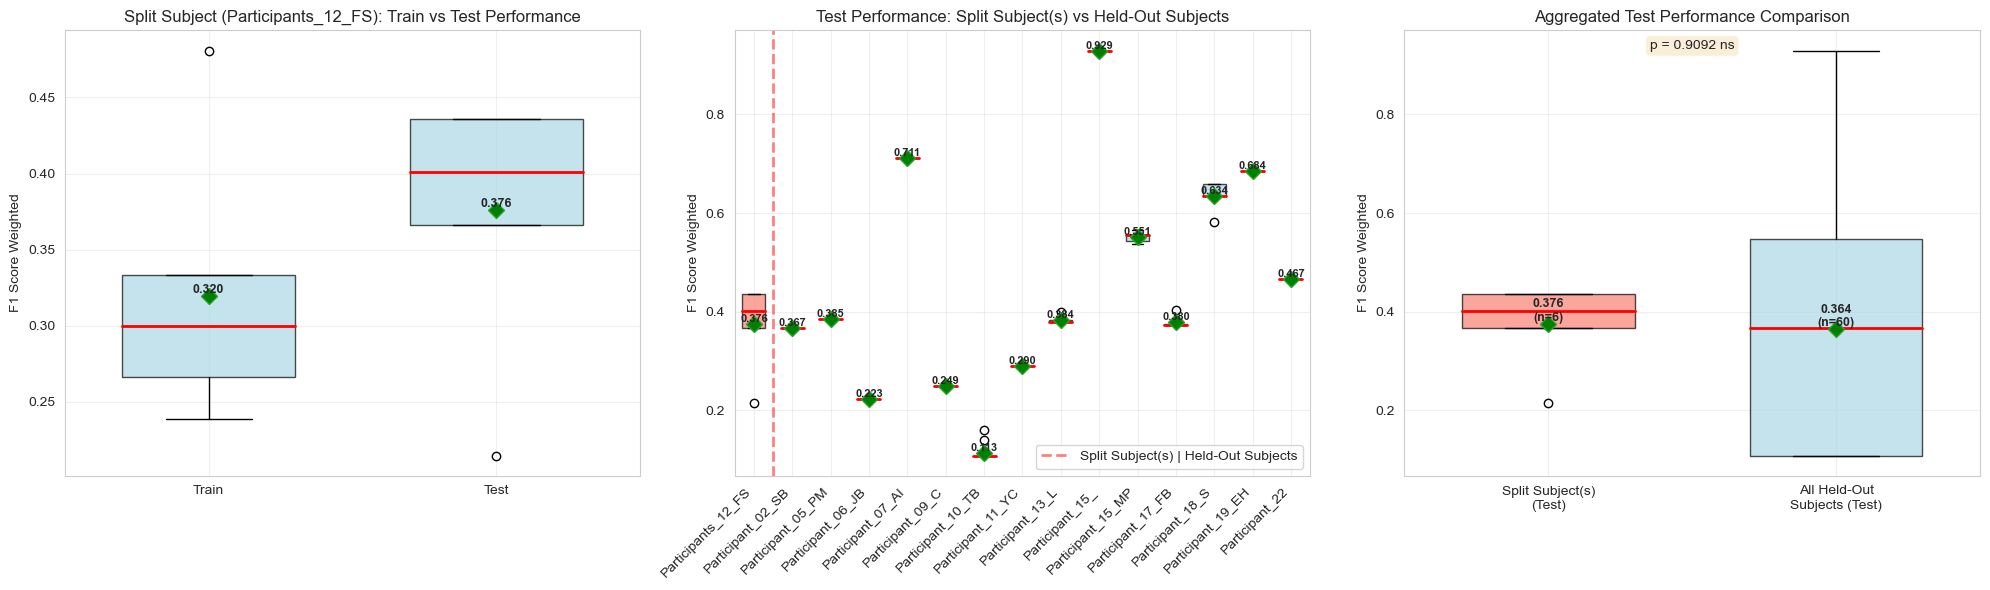

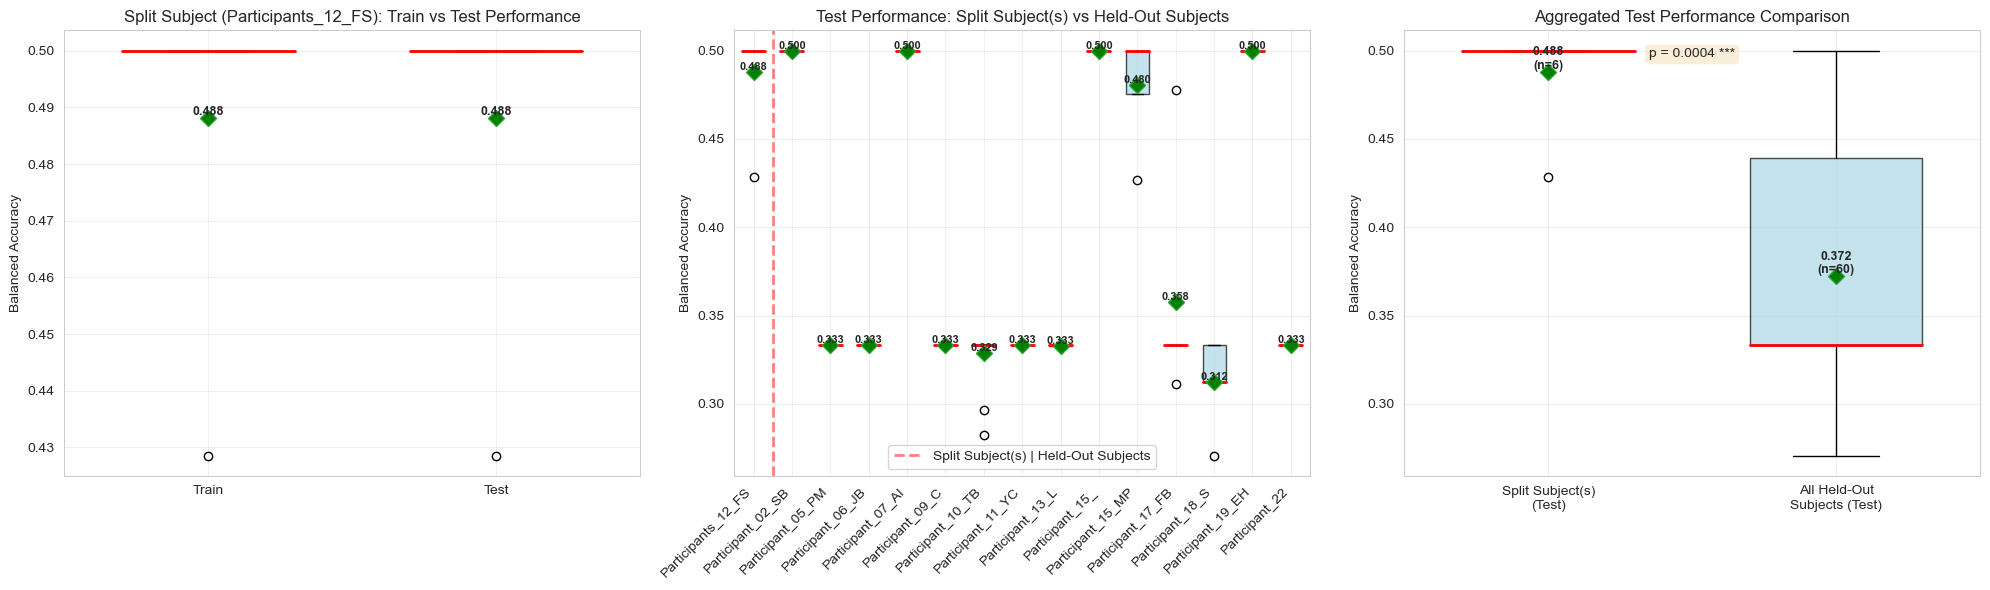

In [ ]:
# 5. Visualizations

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# CONFIGURATION: Set this to a specific split subject ID or "all" to show all split subjects
split_subject_to_plot = "all"  # Options: "all" or specific subject ID like "Participants_12_FS"

for metric in metrics:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Determine which split subjects to display
    if split_subject_to_plot == "all":
        # Get unique split subjects across all runs
        unique_split_subjects = list(set(split_subjects_per_run))
        display_split_subjects = unique_split_subjects
        title_suffix = "All Split Subjects"
    else:
        # Display only the specified split subject
        display_split_subjects = [split_subject_to_plot]
        title_suffix = split_subject_to_plot
    
    # Organize data by split subject
    split_subjects_data = {subj: {'train': [], 'test': []} for subj in display_split_subjects}
    
    for run_idx, run_data in enumerate(all_runs_data):
        split_subj = split_subjects_per_run[run_idx]
        if split_subj in display_split_subjects:
            split_subjects_data[split_subj]['train'].append(run_data['train'][split_subj][metric])
            split_subjects_data[split_subj]['test'].append(run_data['test'][split_subj][metric])
    
    # Plot 1: Split subject(s) train vs test
    ax1 = axes[0]
    
    if split_subject_to_plot == "all":
        # Aggregate all split subjects' train and test data
        all_split_train = []
        all_split_test = []
        for subj in display_split_subjects:
            all_split_train.extend(split_subjects_data[subj]['train'])
            all_split_test.extend(split_subjects_data[subj]['test'])
        
        positions = [1, 2]
        data_to_plot = [all_split_train, all_split_test]
        
        bp1 = ax1.boxplot(data_to_plot, positions=positions, widths=0.6,
                           patch_artist=True, showmeans=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           meanprops=dict(marker='D', markerfacecolor='green', markersize=8))
        
        ax1.set_xticks(positions)
        ax1.set_xticklabels(['Train', 'Test'])
        
        # Add mean values and sample sizes as text
        for i, pos in enumerate(positions):
            mean_val = np.mean(data_to_plot[i])
            n_samples = len(data_to_plot[i])
            ax1.text(pos, mean_val, f'{mean_val:.3f}\n(n={n_samples})', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        # Show single split subject
        positions = [1, 2]
        data_to_plot = [split_subjects_data[split_subject_to_plot]['train'],
                        split_subjects_data[split_subject_to_plot]['test']]
        
        bp1 = ax1.boxplot(data_to_plot, positions=positions, widths=0.6,
                           patch_artist=True, showmeans=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           meanprops=dict(marker='D', markerfacecolor='green', markersize=8))
        
        ax1.set_xticks(positions)
        ax1.set_xticklabels(['Train', 'Test'])
        
        # Add mean values as text
        for i, pos in enumerate(positions):
            mean_val = np.mean(data_to_plot[i])
            ax1.text(pos, mean_val, f'{mean_val:.3f}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax1.set_ylabel(metric.replace('-', ' ').title())
    ax1.set_title(f'Split Subject ({title_suffix}): Train vs Test Performance')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Split subject(s) test vs other subjects test 
    ax2 = axes[1]
    
    # Prepare data for boxplot
    subjects_sorted = sorted(other_subjects_test[metric].keys())
    
    if split_subject_to_plot == "all":
        # Show all split subjects on the left of the red line
        split_subjects_sorted = sorted(display_split_subjects)
        all_subjects = split_subjects_sorted + subjects_sorted
        all_data = [[val for val in split_subjects_data[s]['test']] for s in split_subjects_sorted] + \
                   [[value for value in other_subjects_test[metric][s].values()] for s in subjects_sorted]
        colors = ['salmon'] * len(split_subjects_sorted) + ['lightblue'] * len(subjects_sorted)
        split_line_position = len(split_subjects_sorted) + 0.5
    else:
        # Show only the specified split subject
        all_subjects = [split_subject_to_plot] + subjects_sorted
        all_data = [split_subjects_data[split_subject_to_plot]['test']] + \
                   [[value for value in other_subjects_test[metric][s].values()] for s in subjects_sorted]
        colors = ['salmon'] + ['lightblue'] * len(subjects_sorted)
        split_line_position = 1.5
    
    positions = list(range(1, len(all_subjects) + 1))
    
    bp2 = ax2.boxplot(all_data, positions=positions, widths=0.6,
                       patch_artist=True, showmeans=True,
                       medianprops=dict(color='red', linewidth=2),
                       meanprops=dict(marker='D', markerfacecolor='green', markersize=8))
    
    # Color the boxes
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_xticks(positions)
    ax2.set_xticklabels(all_subjects, rotation=45, ha='right')
    ax2.set_ylabel(metric.replace('-', ' ').title())
    ax2.set_title(f'Test Performance: Split Subject(s) vs Held-Out Subjects')
    ax2.grid(True, alpha=0.3)
    ax2.axvline(x=split_line_position, color='red', linestyle='--', alpha=0.5, linewidth=2,
                label='Split Subject(s) | Held-Out Subjects')
    ax2.legend()
    
    # Add mean values as text
    for i, pos in enumerate(positions):
        mean_val = np.mean(all_data[i])
        ax2.text(pos, mean_val, f'{mean_val:.3f}', 
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Plot 3: Aggregated comparison - Split vs All Other Subjects
    ax3 = axes[2]
    
    # Collect all test performances from split subjects
    all_split_test_agg = []
    for subj in display_split_subjects:
        all_split_test_agg.extend(split_subjects_data[subj]['test'])
    
    # Collect all test performances from other subjects (all runs, all subjects)
    other_subjects_all_runs = []
    for subject, run_dict in other_subjects_test[metric].items():
        other_subjects_all_runs.extend(run_dict.values())
    
    # Data for the two boxplots
    aggregated_data = [
        all_split_test_agg,
        other_subjects_all_runs
    ]
    
    positions = [1, 2]
    colors = ['salmon', 'lightblue']
    
    bp3 = ax3.boxplot(aggregated_data, positions=positions, widths=0.6,
                       patch_artist=True, showmeans=True,
                       medianprops=dict(color='red', linewidth=2),
                       meanprops=dict(marker='D', markerfacecolor='green', markersize=8))
    
    # Color the boxes
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax3.set_xticks(positions)
    ax3.set_xticklabels(['Split Subject(s)\n(Test)', 'All Held-Out\nSubjects (Test)'])
    ax3.set_ylabel(metric.replace('-', ' ').title())
    ax3.set_title('Aggregated Test Performance Comparison')
    ax3.grid(True, alpha=0.3)
    
    # Add mean values and sample sizes as text
    for i, pos in enumerate(positions):
        mean_val = np.mean(aggregated_data[i])
        n_samples = len(aggregated_data[i])
        ax3.text(pos, mean_val, f'{mean_val:.3f}\n(n={n_samples})', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add statistical test result
    t_stat, p_val = stats.ttest_ind(aggregated_data[0], aggregated_data[1])
    sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    ax3.text(1.5, ax3.get_ylim()[1] * 0.98, f'p = {p_val:.4f} {sig_text}',
            ha='center', va='top', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    # plt.savefig(f'inter_subject_analysis_{metric}_3cols.png', dpi=300, bbox_inches='tight')
    # print(f"Saved: inter_subject_analysis_{metric}_3cols.png")
    plt.show()